input Queuing System 

1. Enter arrival distribution (Poisson): drdf
2. Enter service distribution (Exponential): dbd
   -> Enter Arrival Rate (λ): 2
   -> Enter Service Rate (μ): 5
3. Enter number of Servers 'C' (or 'inf'): 1
4. Enter System Capacity 'K' (or 'inf'): 9
5. Enter Population Size (or 'inf'): inf
6. Enter System Discipline (FIFO): sd
Warning Only 'Poisson' arrival is supported for M/M models.
Warning Only 'Exponential' service is supported for M/M models.
Warning Unknown discipline defaulting to FIFO

        SYSTEM OUTPUTS        
###Type of Queuing Model: M/M/1/K

### Probabilities (P0 to Pn):
   P(0) = 0.60006
   P(1) = 0.24003
   P(2) = 0.09601
   P(3) = 0.03840
   P(4) = 0.01536
   P(5) = 0.00614
   P(6) = 0.00246
   P(7) = 0.00098
   P(8) = 0.00039
   P(9) = 0.00016

### ALL Performance Measures:
   L  (Avg in system): 0.6656
   Lq (Avg in queue) : 0.2657
   W  (Avg time sys) : 0.3329
   Wq (Avg time queue): 0.1329

### Rates (λk and μk):
   k=0 -> λk=2.0, μk=0
   k=

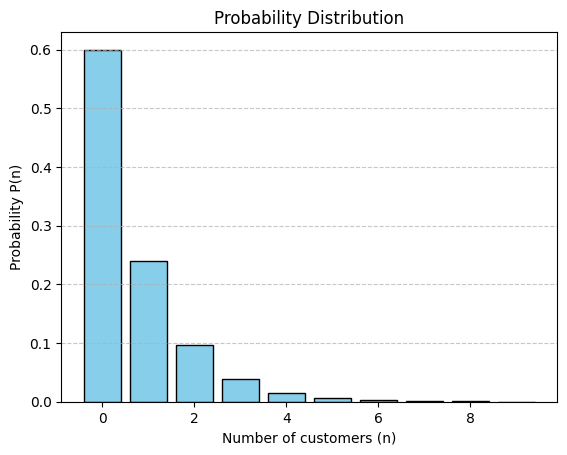

In [19]:
import math
import matplotlib.pyplot as plt


def validate_inputs(arr_dist, srv_dist, lam, mu, c, K, pop_size, discipline):


    arr_dist = arr_dist.strip().lower()
    srv_dist = srv_dist.strip().lower()
    discipline = discipline.strip().upper()
    pop_size = pop_size.strip().lower()

    if arr_dist != "poisson":
        print("Warning Only 'Poisson' arrival is supported for M/M models.")

    if srv_dist != "exponential":
        print("Warning Only 'Exponential' service is supported for M/M models.")

    if lam < 0:
        raise ValueError("Arrival rate λ must be >= 0")

    if mu <= 0:
        raise ValueError("Service rate μ must be > 0")

    if c != float('inf') and c <= 0:
        raise ValueError("Number of servers must be > 0")

    if K != float('inf') and K < 0:
        raise ValueError("Capacity K must be >= 0")

    if pop_size != "inf":
        print("Warning Finite population not supported treated as infinite")

    if discipline not in ["FIFO", "LIFO"]:
        print("Warning Unknown discipline defaulting to FIFO")
        discipline = "FIFO"

    return arr_dist, srv_dist, discipline, pop_size


def detect_model(c, K):
    if c == float('inf'):
        return "M/M/inf"
    elif c == 1 and K == float('inf'):
        return "M/M/1"
    elif c > 1 and K == float('inf'):
        return "M/M/C"
    elif c == 1 and K != float('inf'):
        return "M/M/1/K"
    else:
        return "General"


def compute_pn(model, lam, mu, c, K, n_max=10):
    Pn = []

    if model == "M/M/1":
        rho = lam / mu
        if rho >= 1: return [0]*n_max
        P0 = 1 - rho
        Pn = [(rho**n) * P0 for n in range(n_max)]

    elif model == "M/M/1/K":
        rho = lam / mu
        if rho == 1:
            P0 = 1 / (K + 1)
        else:
            P0 = (1 - rho) / (1 - rho**(K+1))

        limit = min(n_max, K + 1)
        for n in range(limit):
            Pn.append((rho**n) * P0)

    elif model == "M/M/C":
        rho = lam / (c * mu)
        if rho >= 1: return [0]*n_max

        sum_part = sum((lam/mu)**n / math.factorial(n) for n in range(c))
        last_part = ((lam/mu)**c) / (math.factorial(c) * (1 - rho))
        P0 = 1 / (sum_part + last_part)

        for n in range(n_max):
            if n < c:
                Pn.append(((lam/mu)**n / math.factorial(n)) * P0)
            else:
                Pn.append(((lam/mu)**n / (math.factorial(c) * (c**(n-c)))) * P0)

    elif model == "M/M/inf":
        a = lam / mu
        for n in range(n_max):
            Pn.append((a**n * math.exp(-a)) / math.factorial(n))

    return Pn


def compute_performance_measures(model, lam, mu, c, K, Pn):
    if not Pn or sum(Pn) == 0:
        return None, None, None, None

    P0 = Pn[0]

    if model == "M/M/1":
        rho = lam / mu
        L = rho / (1 - rho)
        W = L / lam
        Wq = W - (1 / mu)
        Lq = lam * Wq

    elif model == "M/M/1/K":
        rho = lam / mu
        Pk = Pn[-1] if len(Pn) == K + 1 else 0
        lam_eff = lam * (1 - Pk)

        if rho == 1:
            L = K / 2
        else:
            L = (rho * (1 - (K + 1) * (rho**K) + K * (rho**(K + 1)))) / ((1 - rho) * (1 - rho**(K + 1)))

        W = L / lam_eff if lam_eff > 0 else 0
        Wq = W - (1 / mu)
        Lq = lam_eff * Wq

    elif model == "M/M/C":
        r = lam / mu
        rho = r / c
        Lq = (P0 * (r**c) * rho) / (math.factorial(c) * ((1 - rho)**2))
        Wq = Lq / lam
        W = Wq + (1 / mu)
        L = lam * W

    elif model == "M/M/inf":
        L = lam / mu
        W = 1 / mu
        Lq = 0
        Wq = 0

    return L, Lq, W, Wq


def rates(lam, mu, c, n_max=10):
    lambdas = []
    mus = []

    for k in range(n_max):
        lambdas.append(lam)

        if k == 0:
            mus.append(0)
        elif c == float('inf'):
            mus.append(k * mu)
        elif k <= c:
            mus.append(k * mu)
        else:
            mus.append(c * mu)

    return lambdas, mus


def plot_pn(Pn):
    if not Pn: return
    plt.bar(range(len(Pn)), Pn, color='skyblue', edgecolor='black')
    plt.xlabel("Number of customers (n)")
    plt.ylabel("Probability P(n)")
    plt.title("Probability Distribution")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    plt.close()


def main():
    print("input Queuing System \n")

    arr_dist = input("1. Enter arrival distribution (Poisson): ")
    srv_dist = input("2. Enter service distribution (Exponential): ")
    lam = float(input("   -> Enter Arrival Rate (λ): "))
    mu = float(input("   -> Enter Service Rate (μ): "))

    c = input("3. Enter number of Servers 'C' (or 'inf'): ")
    K = input("4. Enter System Capacity 'K' (or 'inf'): ")
    pop_size = input("5. Enter Population Size (or 'inf'): ")
    discipline = input("6. Enter System Discipline (FIFO): ")

    c = float('inf') if c.lower() == 'inf' else int(c)
    K = float('inf') if K.lower() == 'inf' else int(K)

    arr_dist, srv_dist, discipline, pop_size = validate_inputs(
    arr_dist, srv_dist, lam, mu, c, K, pop_size, discipline
)

    model = detect_model(c, K)

    print("\n" + "="*35)
    print("        SYSTEM OUTPUTS        ")
    print("="*35)
    print("### Type of Queuing Model:", model)

    if c != float('inf'):
        rho = lam / (c * mu)
    else:
        rho = lam / mu

    if rho >= 1 and K == float('inf') and model != "M/M/inf":
        print("\nWARRRRRRRRNING System is UNSTABLE (ρ >= 1) queue will grow to infinity")
        print("Cannot calculate steady state performance measures.")
        return

    Pn = compute_pn(model, lam, mu, c, K)
    print("\n### Probabilities (P0 to Pn):")
    for i, p in enumerate(Pn):
        print(f"   P({i}) = {p:.5f}")

    L, Lq, W, Wq = compute_performance_measures(model, lam, mu, c, K, Pn)
    if L is not None:
        print("\n### All Performance Measures:")
        print(f"   L  (Avg in system): {L:.4f}")
        print(f"   Lq (Avg in queue) : {Lq:.4f}")
        print(f"   W  (Avg time sys) : {W:.4f}")
        print(f"   Wq (Avg time queue): {Wq:.4f}")

    lambdas, mus = rates(lam, mu, c)
    print("\n### Rates (λk and μk):")
    for k in range(len(lambdas)):
        print(f"   k={k} -> λk={lambdas[k]}, μk={mus[k]}")

    print("\nGenerating Plot...")
    plot_pn(Pn)


if __name__ == "__main__":
    try:
        main()
    except Exception as e:
        print("\n Error", e)